### The base element of the antenna system is `AntennaElement`

`AntennaElement` stores far-field radioation, hardware, and system information.

To create an `AntennaElement`, first a far-field radiation pattern is defined that is built from an amplitude and phase patter.

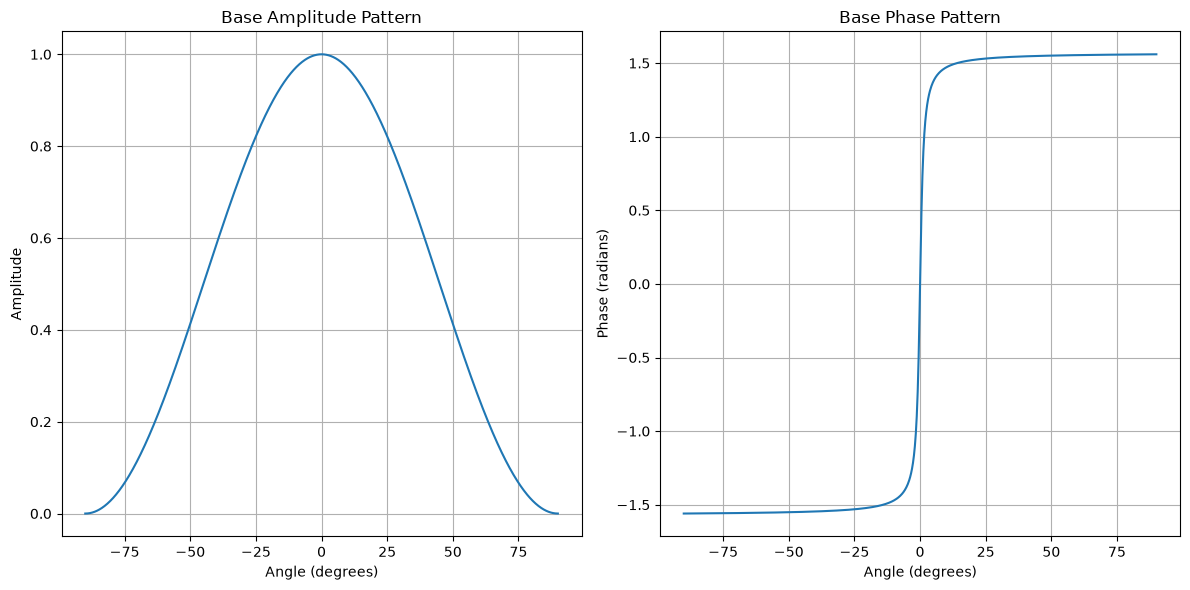

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from antenna.element import Degree, SimpleAmplitudePattern, SimplePhasePattern, RadiationPattern

angles: list[Degree] = np.linspace(-90, 90, 1001)

base_phase_pattern = SimplePhasePattern(angles)

base_amplitude_pattern = SimpleAmplitudePattern(angles)

base_pattern = RadiationPattern(
    amplitude=base_amplitude_pattern,
    phase=base_phase_pattern,
)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(angles, base_amplitude_pattern.pattern)
plt.title("Base Amplitude Pattern")
plt.xlabel("Angle (degrees)")
plt.ylabel("Amplitude")
plt.grid()
plt.subplot(1, 2, 2)
plt.plot(angles, base_phase_pattern.pattern)
plt.title("Base Phase Pattern")
plt.xlabel("Angle (degrees)")
plt.ylabel("Phase (radians)")
plt.grid()
plt.tight_layout()
plt.show()


### Create a single polarization antenna, which can be defined in the `RadiationProperties`

The radiation properties include information about the polarisation of the antenna element, as well.

The patterns for the principal polarisation axes are expected.

In [2]:
from antenna.element import RadiationProperties, RadiationPattern, ZeroAmplitudePattern, ZeroPhasePattern

radiation_properties = RadiationProperties(
    hh_pattern=base_pattern,
    vv_pattern=RadiationPattern(
        amplitude=ZeroAmplitudePattern(angles),
        phase=ZeroPhasePattern(angles),
    ),
    hv_pattern=RadiationPattern(
        amplitude=ZeroAmplitudePattern(angles),
        phase=ZeroPhasePattern(angles),
    ),
)

### Antenna characterisation is mostly done in the frequency domain

The `FrequencyInstance` is a stamp of the antenna behavior for a specific frequency.

The `gain` and `phase` parameters sets the absolute levels of the radiation patterns.

The `axial_ratio` parameter sets the relationship between the principal polarisation axes.

In [3]:
from antenna.element import FrequencyInstance

frequency_instance = FrequencyInstance(
    frequency=77e9,
    radiation=radiation_properties,
    gain=10.0,
    phase=0.0,
    axial_ratio=1.0,
)

### An antenna element is defined by a set of frequency instances and an Rx/Tx definition

In this example, there is only one frequency available

In [4]:
from antenna.element import AntennaElement, RxTMode

antenna_element = AntennaElement(
    frequency_instances=[frequency_instance],
    mode=RxTMode.RECEIVE,
)

### To instantiate an antenna element, an index and a position needs to be assigned

The `AntennElementInstance` provides the directional sampling method of the antenna.

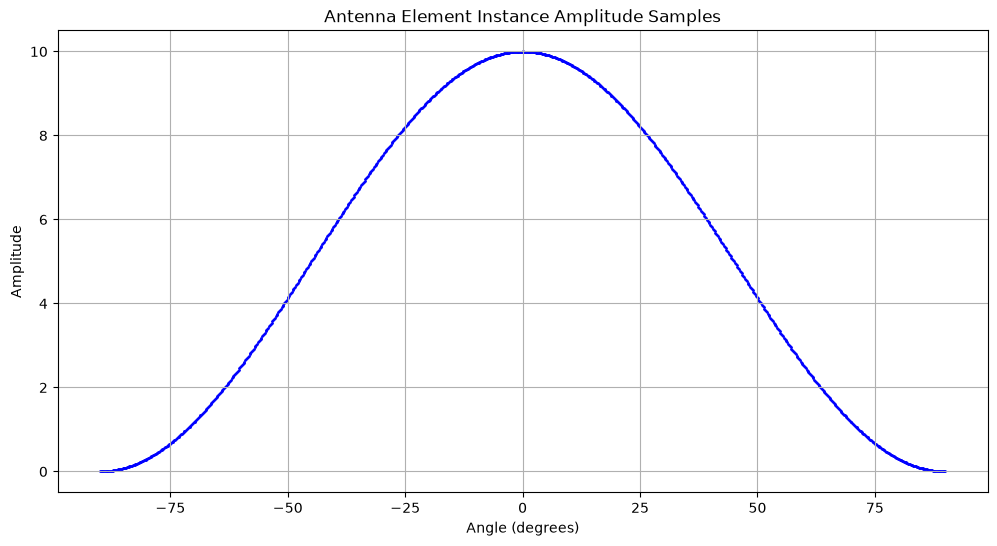

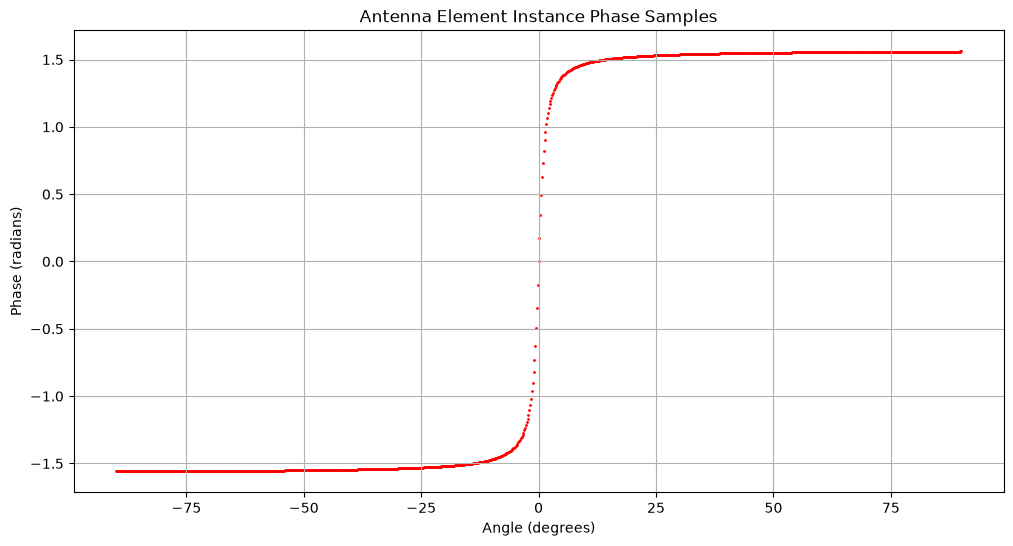

In [5]:
from antenna.element import Position, AntennaElementInstance, Direction

position = Position(x=0.0, y=0.0, z=0.0)

antenna_element_instance = AntennaElementInstance(
    idx=0, position=position, antenna_element=antenna_element
)

frequency = 77e9

plt.figure(figsize=(12, 6))
for angle in angles:
    direction = Direction(azimuth=angle, elevation=0.0)
    plt.scatter(
        angle,
        antenna_element_instance.sample(frequency, direction).amplitude,
        color="blue",
        s=1,
    )
plt.title("Antenna Element Instance Amplitude Samples")
plt.xlabel("Angle (degrees)")
plt.ylabel("Amplitude")
plt.grid()
plt.figure(figsize=(12, 6))
for angle in angles:
    direction = Direction(azimuth=angle, elevation=0.0)
    plt.scatter(
        angle,
        antenna_element_instance.sample(frequency, direction).phase,
        color="red",
        s=1,
    )
plt.title("Antenna Element Instance Phase Samples")
plt.xlabel("Angle (degrees)")
plt.ylabel("Phase (radians)")
plt.grid()
plt.show()